This script takes land use data by parcel from the municipality of Belo Horizonte's City Hall and performs an initial wrangling.

First, land uses are excessively disaggregated for the intended model. Hence, land use types will be aggregated into umbrella categories, which is also helpful to maintain compatibility throughout the time series.

Next, land uses will be inputted into a H3 hexagonal grid.

Finally, some relevant uses of the area will be superimposed in the data. That was necessary because it fixes some inconsistencies found in the original data for some of the years (in 2011, e.g., the airport was classified as a warehouse, and the landfill was marked as vacant). This is also interesting because it fixates the location of the infrastructures and marks the places where the subnormal agglomerates are.

The final sequence of steps, which is shown below, is the result of a trial and error analysis that had to devise solutions to practical issues specific to the data at hand. During this process, a number of intermediate steps are required, all of which are commented and reflected upon just before implementation.

2017 data source: http://bhmap.pbh.gov.br

Data for 2011 and 2020 have been kindly provided by PRODABEL --- https://prefeitura.pbh.gov.br/prodabel

For the years 2011 and 2020, an investigation in QGIS revealed there to be overlapping land use geometries. However, these arethe exception and most overlaps concerned areas of vacant land, while a minor number of instances were residential and retail/services. Therefore, this is not considered an important issue and the overlay operations handle this adequately.

# Preliminaries

In [7]:
import os
from pathlib import Path

#import contextily as cx
import h3
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from geobr import read_municipality
#from h3census.assemble import get_hexagons_with_census_data
from matplotlib.patches import Patch
from shapely.geometry import Point
from tobler.area_weighted import area_interpolate

%matplotlib inline
%config InlineBackend.figure_format='retina'

## Parent Folders

In [8]:
DATABASE = Path(
    os.environ.get('DB_FOLDER')
    )

OUT_FOLDER = os.environ.get('OUT_FOLDER')
OUT_DIR = Path(OUT_FOLDER) / 'A'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
pop_data = gpd.read_parquet(OUT_DIR / 'sociodemografia/sociodemografia.parquet')

In [10]:
hexes = []
for resolution in [9, 10, 11]:
    inpath = OUT_DIR / f'land_uses/uses_by_hex_r{resolution}.parquet'
    h = gpd.read_parquet(inpath)
    hexes.append(h)

hexes = pd.concat(hexes)

In [11]:
hexes.sample(5)

,hex_id,aperture,ano,uso_do_solo,margem_dominancia,entropia_uso_do_solo,geometry,densidade,categoria_uso_do_solo
217846,8ba88cdb0055fff,11,2017,residential,0.245141,0.671014,"POLYGON ((610707.942 7795430.833, 610723.904 7...",low,active
4157,8ba88cdb0badfff,11,2011,retail/services,0.179942,0.570833,"POLYGON ((610097.2 7794870.744, 610113.162 779...",low,active
357355,8ba881a4b5a2fff,11,2018,public services,0.914149,0.180823,"POLYGON ((603113.381 7790517.683, 603082.938 7...",<NA>,static
525832,8ba88cda2a21fff,11,2020,uncharted,0.259398,0.659116,"POLYGON ((605396.274 7795167.075, 605412.23 77...",<NA>,passive
515386,8ba88cd93882fff,11,2020,mixed,0.526732,0.980466,"POLYGON ((613448.734 7803155.838, 613464.705 7...",high,active


In [13]:
pop_data.sample(3)

,,,geometry,habitantes,domicilios,rendimento_medio,rendimento_medio_responsaveis,decile,habitantes_grid,var_habitantes
hex_id,year,aperture,,,,,,,,
8ba88cda2535fff,2010,11,"POLYGON ((607450.921 7795067.56, 607466.88 779...",33,14,1589,2403,8,75,3
8ba88cda3128fff,2022,11,"POLYGON ((604104.54 7796352.699, 604120.495 77...",16,8,3915,0,7,11,1
8aa88cd96807fff,2010,10,"POLYGON ((615255.243 7799241.295, 615179.838 7...",226,68,708,1295,4,188,-48


In [15]:
idx = set(pop_data.loc[pop_data.habitantes_grid < 1].reset_index().hex_id.drop_duplicates())

In [18]:
hexes.loc[hexes.hex_id.isin(idx)].uso_do_solo.value_counts()

uso_do_solo
amenities          48965
vacant             32615
uncharted          24072
public services    13665
infrastructure      7630
industry            7055
retail/services     4013
residential         2886
mixed               1207
Name: count, dtype: int64

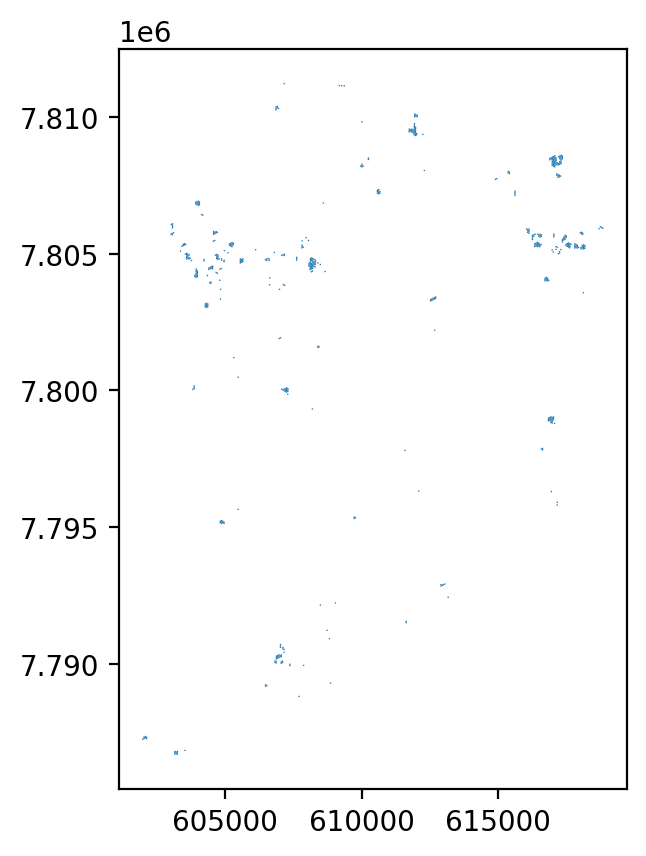

In [34]:
hexes.loc[hexes.hex_id.isin(idx) & (hexes['aperture'] == 11) & (hexes['ano'] == 2022) & (hexes['uso_do_solo'] == 'residential')].plot()
plt.show()

In [25]:
hexes.dtypes

hex_id                           object
aperture                          int64
ano                               int64
uso_do_solo                      object
margem_dominancia               float64
entropia_uso_do_solo            float64
geometry                       geometry
densidade                string[python]
categoria_uso_do_solo            object
dtype: object